In [1]:
import os

os.environ['PYTHONWARNINGS'] = 'ignore::UserWarning'

import numpy as np
import scipy.sparse
import pickle
import time
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import StackingClassifier, VotingClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MaxAbsScaler
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve
)
from xgboost import XGBClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import ExtraTreesClassifier

In [2]:
# load preprocessed data
X_train = scipy.sparse.load_npz('../data_processed/X_train.npz')
X_val = scipy.sparse.load_npz('../data_processed/X_val.npz')
X_test = scipy.sparse.load_npz('../data_processed/X_test.npz')
y_train = np.load('../data_processed/y_train.npy')
y_val = np.load('../data_processed/y_val.npy')
y_test = np.load('../data_processed/y_test.npy')

with open('../models/label_encoder.pkl', 'rb') as f:
    le = pickle.load(f)

label_names = list(le.classes_)
print(f"train: {X_train.shape}, classes: {Counter(y_train)}")
print(f"val: {X_val.shape}")
print(f"test: {X_test.shape}")
print(f"labels: {label_names}")

train: (176638, 3004), classes: Counter({0: 88319, 1: 88319})
val: (13064, 3004)
test: (26128, 3004)
labels: ['Doctor Consultation', 'OTC Drug']


In [3]:
# evaluation function
def evaluate(name, model, X_test, y_test, label_names):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test) if hasattr(model, 'predict_proba') else None

    acc = accuracy_score(y_test, y_pred)
    weighted_f1 = f1_score(y_test, y_pred, average='weighted')
    macro_f1 = f1_score(y_test, y_pred, average='macro')
    report = classification_report(y_test, y_pred,
                                   target_names=label_names,
                                   output_dict=True)

    # safety metrics
    doctor_recall = report['Doctor Consultation']['recall']
    otc_precision = report['OTC Drug']['precision']
    otc_recall = report['OTC Drug']['recall']

    auc = None
    if y_proba is not None:
        try:
            auc = roc_auc_score(y_test, y_proba[:, 1])
        except Exception:
            pass

    print(f"\n{name}")
    print(f"accuracy: {acc:.4f}")
    print(f"weighted f1: {weighted_f1:.4f} (primary)")
    print(f"macro f1: {macro_f1:.4f}")
    print(f"doctor recall: {doctor_recall:.4f}")
    print(f"otc precision: {otc_precision:.4f}")
    print(f"otc recall: {otc_recall:.4f}")
    if auc:
        print(f"auc-roc: {auc:.4f}")
    print(classification_report(y_test, y_pred, target_names=label_names))

    return {
        'name': name,
        'model': model,
        'accuracy': acc,
        'weighted_f1': weighted_f1,
        'macro_f1': macro_f1,
        'doctor_recall': doctor_recall,
        'otc_precision': otc_precision,
        'otc_recall': otc_recall,
        'auc': auc,
        'y_pred': y_pred,
    }

In [4]:
# Define models

def get_logistic_regression(max_iter: int = 1000):
    """
    Create Logistic Regression model.
    :param max_iter: Maximum number of iterations.
    :return: LogisticRegression model instance.
    """
    return LogisticRegression(
        max_iter=max_iter,
        solver='saga',
        random_state=42
    )


def get_multinomial_nb():
    """
    Create Multinomial Naive Bayes model.
    :return: MultinomialNB model instance.
    """
    return MultinomialNB(alpha=0.1)


def get_linear_svm():
    """
    Create calibrated Linear SVM model.
    :return: CalibratedClassifierCV model instance.
    """
    return CalibratedClassifierCV(
        estimator=LinearSVC(random_state=42),
        cv=3
    )


def get_extra_trees():
    """
    Create Extra Trees classifier.
    :return: ExtraTreesClassifier model instance.
    """
    return ExtraTreesClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )


def get_xgboost(n_estimators: int = 100):
    """
    Create XGBoost classifier.
    :param n_estimators: Number of boosting estimators.
    :return: XGBClassifier model instance.
    """
    return XGBClassifier(
        n_estimators=n_estimators,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.3,
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    )


def get_meta_learner():
    """
    Create Logistic Regression meta-learner for stacking.
    :return: LogisticRegression model instance.
    """
    return LogisticRegression(
        max_iter=500,
        solver='saga',
        random_state=42
    )


# Single models

lr = get_logistic_regression()
nb = get_multinomial_nb()
svm = get_linear_svm()
extra_trees = get_extra_trees()
xgb = get_xgboost(n_estimators=200)

# Ensemble models

stack_svm_et_xgb = StackingClassifier(
    estimators=[
        ('svm', get_linear_svm()),
        ('et', get_extra_trees()),
        ('xgb', get_xgboost())
    ],
    final_estimator=get_meta_learner(),
    cv=5,
    n_jobs=-1
)

voting_svm_et_xgb = VotingClassifier(
    estimators=[
        ('svm', get_linear_svm()),
        ('et', get_extra_trees()),
        ('xgb', get_xgboost())
    ],
    voting='soft',
    weights=[2, 4, 2],
    n_jobs=-1
)

mlp_pipeline = Pipeline([
    ('scaler', MaxAbsScaler()),
    ('mlp', MLPClassifier(
        hidden_layer_sizes=(256, 128, 64),
        activation='relu', solver='adam',
        learning_rate_init=0.001, batch_size=512,
        max_iter=300, early_stopping=True,
        validation_fraction=0.1, n_iter_no_change=15,
        random_state=42, verbose=False
    ))
])

stack_mlp_et_xgb = StackingClassifier(
    estimators=[
        ('mlp', mlp_pipeline),
        ('et', get_extra_trees()),
        ('xgb', get_xgboost())
    ],
    final_estimator=get_meta_learner(),
    cv=5,
    n_jobs=-1
)

models = {
    'Logistic Regression': lr,
    'Multinomial Naive Bayes': nb,
    'Linear SVM': svm,
    'Extra Trees': extra_trees,
    'XGBoost': xgb,
    'Stacking SVM+ET+XGB': stack_svm_et_xgb,
    'Soft Voting SVM+ET+XGB': voting_svm_et_xgb,
    'Stacking MLP+ET+XGB': stack_mlp_et_xgb,
}

print(f"{len(models)} models defined")

8 models defined


In [5]:
# Train all models and evaluate on test set
results = {}

for name, model in models.items():
    print(f"\nStarting training for: {name}")

    start = time.time()
    model.fit(X_train, y_train)

    elapsed = time.time() - start

    print(f"Finished training {name}")
    print(f"Training time: {int(elapsed // 60)} minutes {int(elapsed % 60)} seconds")

    val_acc = accuracy_score(y_val, model.predict(X_val))
    print(f"Validation accuracy: {val_acc:.4f}")

    print("Evaluating on test set")
    results[name] = evaluate(name, model, X_test, y_test, label_names)
    results[name]['train_time'] = elapsed

    fname = name.lower().replace(' ', '_').replace('+', '_')
    with open(f'../models/{fname}.pkl', 'wb') as file:
        pickle.dump(model, file)

    print(f"Model saved to: ../models/{fname}.pkl")
    print("\n")


Starting training for: Logistic Regression
Finished training Logistic Regression
Training time: 0 minutes 10 seconds
Validation accuracy: 0.9444
Evaluating on test set

Logistic Regression
accuracy: 0.9474
weighted f1: 0.9579 (primary)
macro f1: 0.7647
doctor recall: 0.9467
otc precision: 0.3912
otc recall: 0.9686
auc-roc: 0.9876
                     precision    recall  f1-score   support

Doctor Consultation       1.00      0.95      0.97     25235
           OTC Drug       0.39      0.97      0.56       893

           accuracy                           0.95     26128
          macro avg       0.70      0.96      0.76     26128
       weighted avg       0.98      0.95      0.96     26128

Model saved to: ../models/logistic_regression.pkl



Starting training for: Multinomial Naive Bayes
Finished training Multinomial Naive Bayes
Training time: 0 minutes 0 seconds
Validation accuracy: 0.8821
Evaluating on test set

Multinomial Naive Bayes
accuracy: 0.8848
weighted f1: 0.9169 (primary

In [6]:
print("\nresults summary:")
print(f"{'model':<30} {'wf1':>6} {'mf1':>6} {'docr':>6} {'otcp':>6} {'auc':>6} {'time':>7}")
print("-" * 78)

for name, res in results.items():
    elapsed = res.get('train_time', 0)
    minutes = int(elapsed // 60)
    seconds = int(elapsed % 60)

    auc = res['auc']
    auc_text = f"{auc:.4f}" if auc is not None else "N/A"

    print(
        f"{name:<30} "
        f"{res['weighted_f1']:>6.4f} "
        f"{res['macro_f1']:>6.4f} "
        f"{res['doctor_recall']:>6.4f} "
        f"{res['otc_precision']:>6.4f} "
        f"{auc_text:>6} "
        f"{minutes:>2}m{seconds:02d}s"
    )

best = max(results.items(), key=lambda x: x[1]['weighted_f1'])
best = {'name': best[0], **best[1]}


results summary:
model                             wf1    mf1   docr   otcp    auc    time
------------------------------------------------------------------------------
Logistic Regression            0.9579 0.7647 0.9467 0.3912 0.9876  0m10s
Multinomial Naive Bayes        0.9169 0.6453 0.8835 0.2189 0.9558  0m00s
Linear SVM                     0.9660 0.7965 0.9595 0.4538 0.9889  0m03s
Extra Trees                    0.9837 0.8767 0.9917 0.7644 0.9788  1m35s
XGBoost                        0.9363 0.6912 0.9148 0.2783 0.9736  0m08s
Stacking SVM+ET+XGB            0.9842 0.8780 0.9933 0.7944 0.9908  7m12s
Soft Voting SVM+ET+XGB         0.9827 0.8773 0.9855 0.6798 0.9925  1m01s
Stacking MLP+ET+XGB            0.9867 0.8964 0.9950 0.8443 0.9913 12m10s


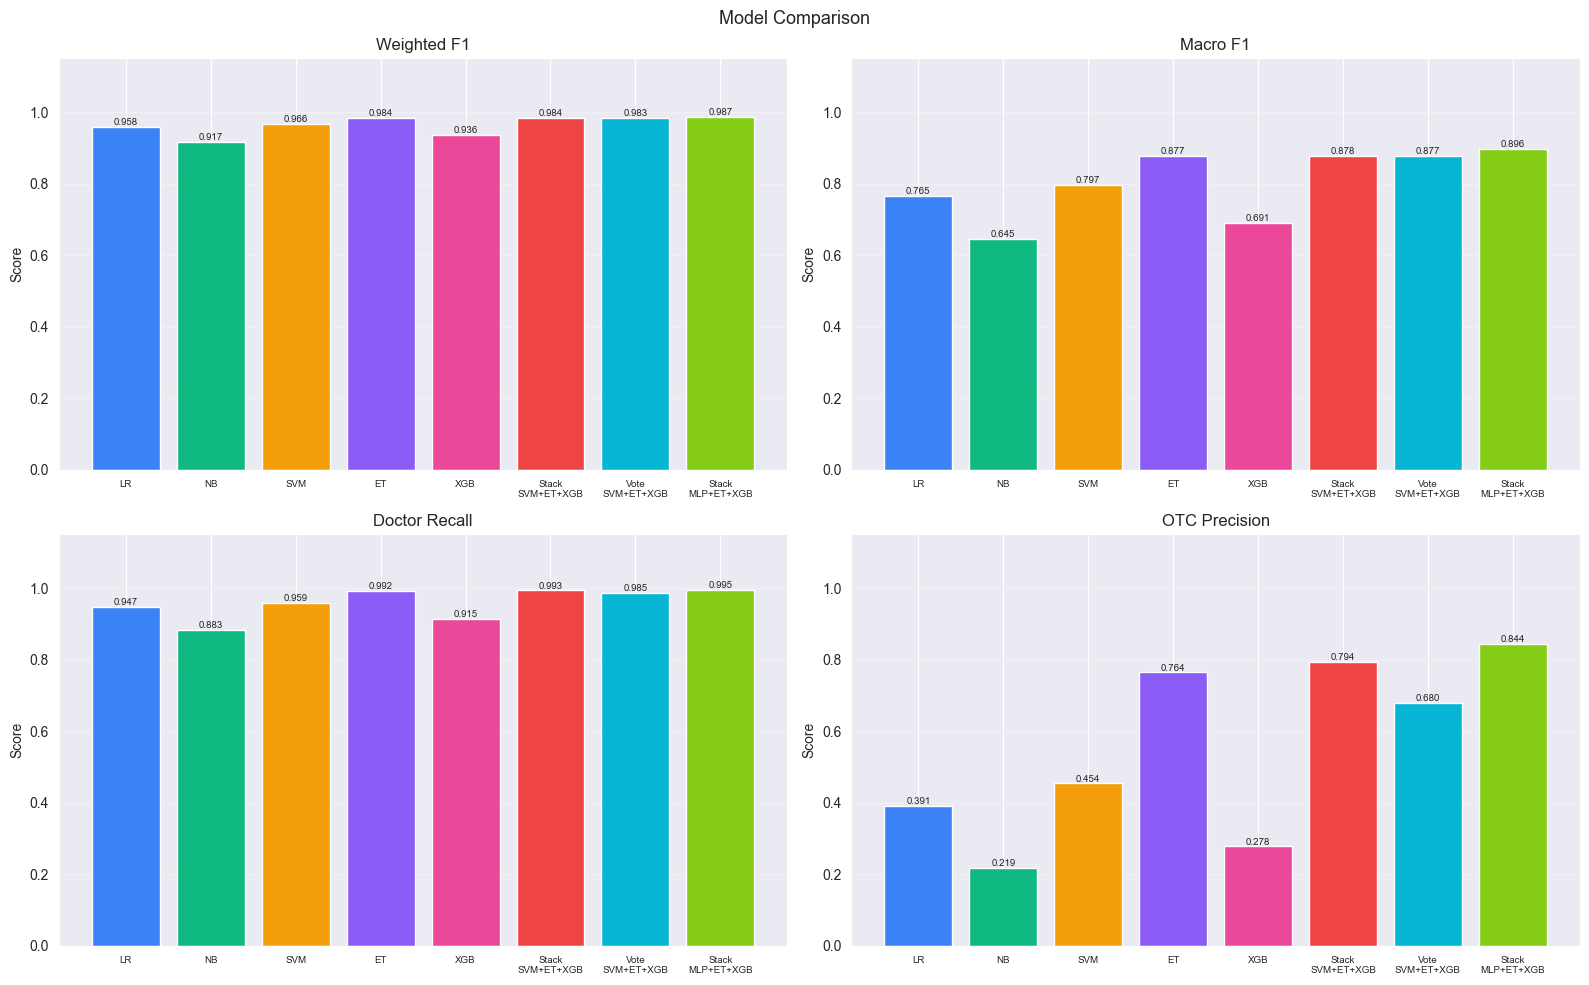

In [7]:
metrics = ['weighted_f1', 'macro_f1', 'doctor_recall', 'otc_precision']
metric_labels = ['Weighted F1', 'Macro F1', 'Doctor Recall', 'OTC Precision']
short_names = ['LR', 'NB', 'SVM', 'ET', 'XGB', 'Stack\nSVM+ET+XGB', 'Vote\nSVM+ET+XGB', 'Stack\nMLP+ET+XGB']
colors = ['#3B82F6', '#10B981', '#F59E0B', '#8B5CF6', '#EC4899', '#EF4444', '#06B6D4', '#84CC16']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Model Comparison', fontsize=13)

for ax, metric, label in zip(axes.flatten(), metrics, metric_labels):
    values = [results[name][metric] for name in models]
    bars = ax.bar(short_names, values, color=colors, edgecolor='white')
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', fontsize=7)
    ax.set_title(label)
    ax.set_ylim(0, 1.15)
    ax.set_ylabel('Score')
    ax.tick_params(axis='x', labelsize=7)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../results/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

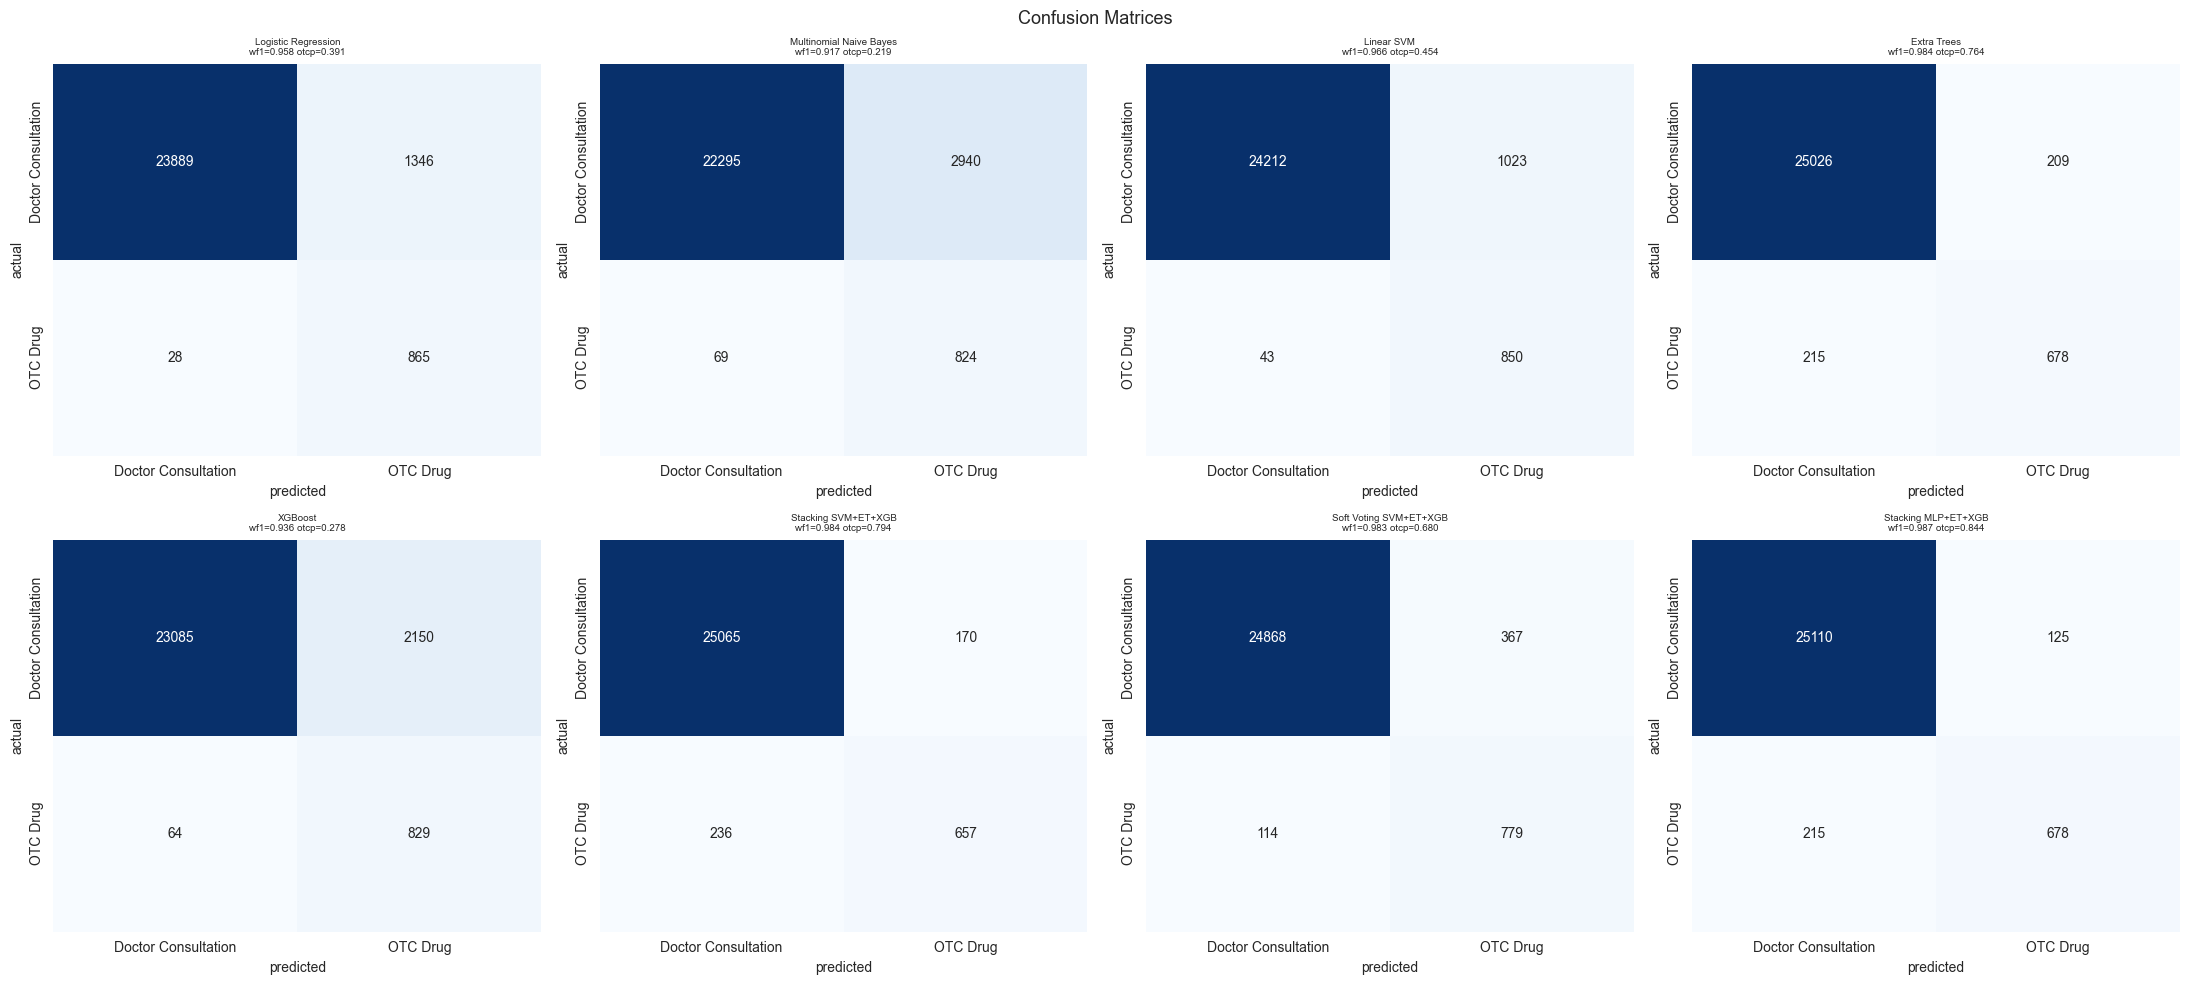

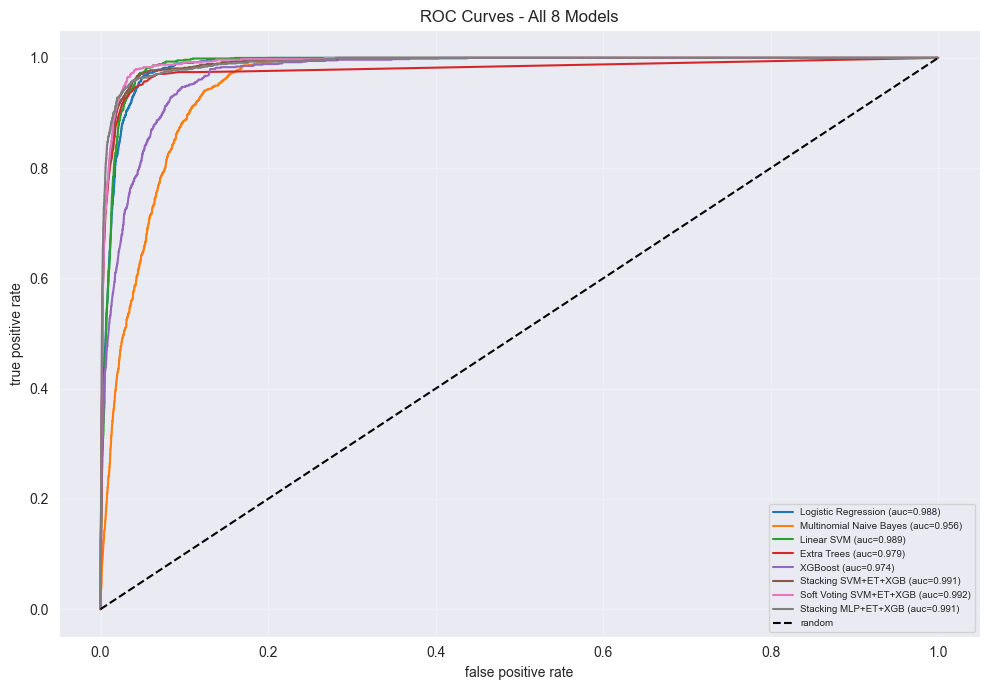


done
best model: Stacking MLP+ET+XGB
models saved to ../models/


In [8]:
# confusion matrices for all 8 models
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
fig.suptitle('Confusion Matrices', fontsize=13)

for ax, (name, res) in zip(axes.flatten(), results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_names, yticklabels=label_names,
                ax=ax, cbar=False)
    ax.set_title(f"{name}\nwf1={res['weighted_f1']:.3f} otcp={res['otc_precision']:.3f}",
                 fontsize=7)
    ax.set_xlabel('predicted')
    ax.set_ylabel('actual')

plt.tight_layout()
plt.savefig('../results/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

# ROC curves for all 8 models
fig, ax = plt.subplots(figsize=(10, 7))

for name, res in results.items():
    if res['auc']:
        y_proba = res['model'].predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        ax.plot(fpr, tpr, label=f"{name} (auc={res['auc']:.3f})")

ax.plot([0, 1], [0, 1], 'k--', label='random')
ax.set_xlabel('false positive rate')
ax.set_ylabel('true positive rate')
ax.set_title('ROC Curves - All 8 Models')
ax.legend(fontsize=7)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../results/roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print("\ndone")
print(f"best model: {best['name']}")
print("models saved to ../models/")